In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib_venn import venn2
import os

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11



✓ Libraries loaded successfully!


In [23]:
#LOAD MY ANNOTATED PEAKS
peaks = pd.read_csv('results/annotated_peaks.txt', sep='\t')
print(f"\n Loaded {len(peaks):,} annotated peaks")


# Show summary

print("PEAK ANNOTATION SUMMARY")

print(peaks['Annotation'].value_counts().head(10))




 Loaded 10,076 annotated peaks
PEAK ANNOTATION SUMMARY
Annotation
Intergenic                                     1750
intron (ENST00000637419.1, intron 2 of 2)        12
intron (ENST00000628795.2, intron 1 of 2)         5
intron (ENST00000486113.1, intron 2 of 2)         4
intron (ENST00000481739.2, intron 1 of 9)         4
intron (ENST00000389416.8, intron 1 of 21)        4
intron (ENST00000409483.5, intron 11 of 21)       4
intron (ENST00000587024.5, intron 1 of 31)        3
intron (ENST00000369543.6, intron 1 of 18)        3
intron (ENST00000370074.8, intron 3 of 5)         3
Name: count, dtype: int64


In [24]:
promoter_peaks = peaks[peaks['Annotation'].str.contains('promoter-TSS', na=False)]
chipseq_genes = set(promoter_peaks['Gene Name'].dropna().unique())

print(f"\n✓ Found {len(chipseq_genes)} unique genes with peaks at promoter-TSS")



✓ Found 4148 unique genes with peaks at promoter-TSS


In [14]:
print("\n" + "="*60)
print("FIGURES 2D & 2E: MALAT1 and NEAT1 Analysis")
print("="*60)

target_genes = ['MALAT1', 'NEAT1']

for gene in target_genes:
    gene_peaks = peaks[peaks['Gene Name'] == gene]
    print(f"\n {gene}:")
    if len(gene_peaks) > 0:
        print(f"   ✓ Found {len(gene_peaks)} peak(s)")
        for idx, row in gene_peaks.iterrows():
            print(f"     - {row['Chr']}:{row['Start']}-{row['End']}")
            print(f"       Annotation: {row['Annotation']}")
            print(f"       Distance to TSS: {row['Distance to TSS']} bp")
    else:
        print(f"    No peaks found")


FIGURES 2D & 2E: MALAT1 and NEAT1 Analysis

 MALAT1:
   ✓ Found 2 peak(s)
     - chr11:65498940-65499166
       Annotation: promoter-TSS (ENST00000508832.3)
       Distance to TSS: 2.0 bp
     - chr11:65497533-65497662
       Annotation: promoter-TSS (ENST00000534336.3)
       Distance to TSS: -43.0 bp

 NEAT1:
    No peaks found


In [18]:

print("FIGURE 2F: ChIP-seq vs RNA-seq Overlap (Conceptual)")


# From the paper: 466 down-regulated + 687 up-regulated = 1153 total DE genes
# Significance thresholds: padj < 0.01, |log2FC| > 1

paper_de_genes = 1153
our_chipseq_genes = len(chipseq_genes)

print(f"\ Paper's Results (Barutcu et al. 2016):")
print(f"   - Total DE genes: {paper_de_genes}")
print(f"   - Down-regulated: 466")
print(f"   - Up-regulated: 687")
print(f"   - Thresholds: padj < 0.01, |log2FC| > 1")

print(f"\n Your ChIP-seq Results:")
print(f"   - Genes with promoter-TSS peaks: {our_chipseq_genes}")


FIGURE 2F: ChIP-seq vs RNA-seq Overlap (Conceptual)
\ Paper's Results (Barutcu et al. 2016):
   - Total DE genes: 1153
   - Down-regulated: 466
   - Up-regulated: 687
   - Thresholds: padj < 0.01, |log2FC| > 1

 Your ChIP-seq Results:
   - Genes with promoter-TSS peaks: 4148


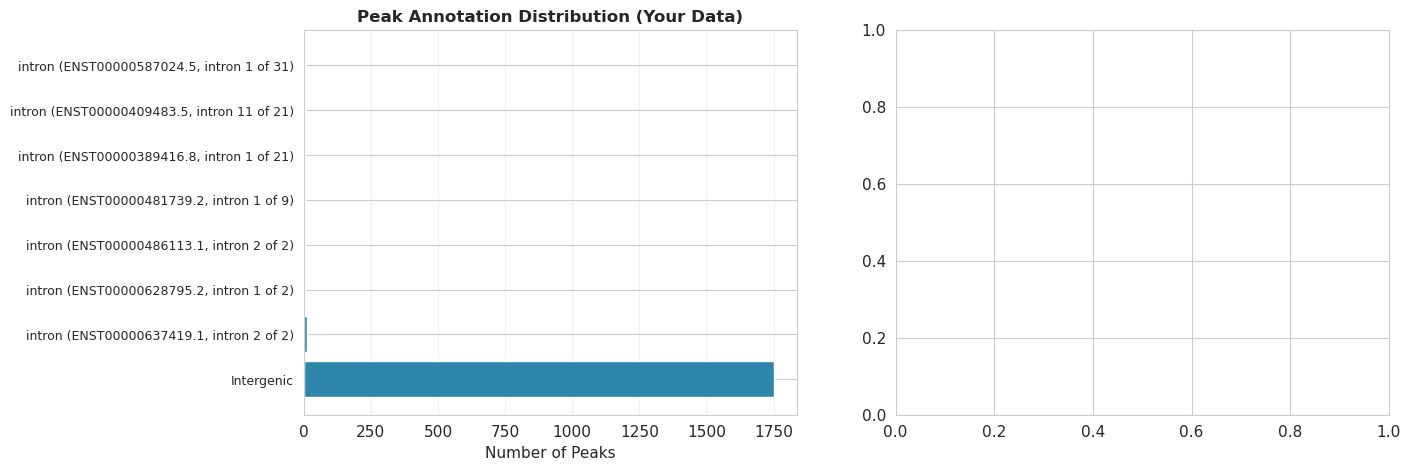

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Peak annotation distribution
annotation_counts = peaks['Annotation'].value_counts().head(8)
ax1.barh(range(len(annotation_counts)), annotation_counts.values, color='#2E86AB')
ax1.set_yticks(range(len(annotation_counts)))
ax1.set_yticklabels(annotation_counts.index, fontsize=9)
ax1.set_xlabel('Number of Peaks', fontsize=11)
ax1.set_title('Peak Annotation Distribution (Your Data)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

In [20]:
categories = ['ChIP-seq\n(Your peaks)', 'RNA-seq\n(Paper: DE genes)']
values = [our_chipseq_genes, paper_de_genes]
colors = ['#2E86AB', '#A23B72']
ax2.bar(categories, values, color=colors, alpha=0.7)
ax2.set_ylabel('Number of Genes', fontsize=11)
ax2.set_title('Gene Counts: Your ChIP vs Paper RNA-seq', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for i, v in enumerate(values):
    ax2.text(i, v + 30, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('results/week4_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Figure saved: results/week4_analysis.png")
plt.show()


✓ Figure saved: results/week4_analysis.png


<Figure size 1000x600 with 0 Axes>

In [21]:
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print(f"\nYour ChIP-seq Results:")
print(f"  • Total peaks called: {len(peaks):,}")
print(f"  • Unique genes with peaks: {len(peaks['Gene Name'].dropna().unique()):,}")
print(f"  • Genes with promoter-TSS peaks: {our_chipseq_genes:,}")
print(f"  • % peaks at promoter-TSS: {100*len(promoter_peaks)/len(peaks):.1f}%")

print(f"\nPaper's RNA-seq Results (for reference):")
print(f"  • Total DE genes: {paper_de_genes:,}")
print(f"  • Significance: padj < 0.01, |log2FC| > 1")

print("\n" + "="*60)


SUMMARY STATISTICS

Your ChIP-seq Results:
  • Total peaks called: 10,076
  • Unique genes with peaks: 8,165
  • Genes with promoter-TSS peaks: 4,148
  • % peaks at promoter-TSS: 43.0%

Paper's RNA-seq Results (for reference):
  • Total DE genes: 1,153
  • Significance: padj < 0.01, |log2FC| > 1

